In [1]:
import sys
import os
import re
import json
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from IPython.display import HTML, display
import html

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset
from captum.attr import LayerIntegratedGradients

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    build_ranking_specs,
    collect_token_indices_from_items,
    highlight_spans,
    make_json_serializable,
    mask_spans_in_text,
    predict_with_pipeline,
    rank_indices_by_score,
    save_aopc_outputs,
    select_top_fraction_indices,
    trim_char_span,
)

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
if torch.cuda.is_available():
    TORCH_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TORCH_DEVICE = torch.device("mps")
else:
    TORCH_DEVICE = torch.device("cpu")

DEVICE = TORCH_DEVICE

# Integrated Gradients settings
N_STEPS = 16
INTERNAL_BATCH_SIZE = 4

# Config search settings
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]

ABLATION_MODE = "mask"

# Output
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "ig_results"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

Pipeline device: mps
Torch device: mps


In [3]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

# Resolve class index for LABEL_1.
if hasattr(model.config, "label2id") and INAPPROPRIATE_LABEL in model.config.label2id:
    TARGET_CLASS_IDX = int(model.config.label2id[INAPPROPRIATE_LABEL])
else:
    id2label = {int(k): v for k, v in model.config.id2label.items()}
    TARGET_CLASS_IDX = [k for k, v in id2label.items() if v == INAPPROPRIATE_LABEL][0]

# Baseline token for Integrated Gradients.
# PAD is used as the default reference input. If unavailable, fall back to MASK or UNK.
if tokenizer.pad_token_id is not None:
    BASELINE_TOKEN_ID = tokenizer.pad_token_id
elif tokenizer.mask_token_id is not None:
    BASELINE_TOKEN_ID = tokenizer.mask_token_id
else:
    BASELINE_TOKEN_ID = tokenizer.unk_token_id

# Embedding layer used by Captum's LayerIntegratedGradients.
base_model = getattr(model, model.base_model_prefix)
embedding_layer = base_model.embeddings

print("Mask token:", MASK_TOKEN)
print("Baseline token id:", BASELINE_TOKEN_ID)
print("Model labels:", model.config.id2label)
print("Target class index:", TARGET_CLASS_IDX)
print("Embedding layer:", embedding_layer.__class__.__name__)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Mask token: [MASK]
Baseline token id: 0
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Target class index: 1
Embedding layer: DebertaV2Embeddings


# Load prepared data

In [4]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

All: (2191, 30)
Train: (1533, 30)
Validation: (220, 30)
Test: (438, 30)
Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# Integrated-Gradients-based span localization

This notebook evaluates Integrated Gradients as a gradient-based span localization method for the document-level inappropriateness classifier.

The method uses only `post_text` as input. It computes token-level attributions for the `inappropriate` class and then aggregates subword attributions to word-level scores. Candidate spans are created by selecting high-attribution words and merging nearby selected words into readable text spans.

The resulting spans are validated through perturbation masking. If masking the selected span decreases the model's predicted probability of `LABEL_1`, the span is treated as more faithful to the document-level prediction.

The tuned hyperparameters are:

- `quantile`
- `window_size`

## Quantile and window size

Integrated Gradients produces signed attribution scores. In this notebook, only positive word-level attributions are used for span extraction because the target is to identify words that contribute positively to the `inappropriate` class.

### Quantile

The `quantile` controls how selective the method is when choosing words based on positive IG scores.

For example:

- `quantile = 0.80` selects words in the top 20% of the positive attribution-score distribution.
- `quantile = 0.90` selects words in the top 10%.
- `quantile = 0.95` selects only the strongest positive words.

Higher quantiles usually produce shorter and more focused spans. Lower quantiles produce longer and more inclusive spans.

### Window size

In this notebook, `window_size` is used as a merge-gap parameter. It does **not** add a fixed number of words to the left and right of each selected word. Instead, it determines how many unselected words may lie between selected words for them to be merged into one span.

For example:

```text
selected_word   unselected_word   selected_word

In [5]:
def forward_func(input_ids, attention_mask):
    """
    Forward function used by Captum.
    
    It returns the logit of the inappropriate class.
    Logits are used instead of probabilities to reduce saturation effects.
    """
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )
    return outputs.logits[:, TARGET_CLASS_IDX]


lig = LayerIntegratedGradients(forward_func, embedding_layer)


def make_reference_input_ids(input_ids):
    """
    Build reference input IDs for Integrated Gradients.
    
    Special tokens are kept unchanged. All real text tokens are replaced by
    the baseline token.
    """
    ref_input_ids = input_ids.clone()
    special_ids = set(tokenizer.all_special_ids)
    
    token_list = input_ids[0].detach().cpu().tolist()
    
    for i, token_id in enumerate(token_list):
        if token_id not in special_ids:
            ref_input_ids[0, i] = BASELINE_TOKEN_ID
    
    return ref_input_ids

In [6]:
def compute_ig_data(text, max_length=MAX_LENGTH, n_steps=N_STEPS):
    """
    Compute raw-token Integrated Gradients for one text.

    This version does not aggregate subword tokens to words.
    It keeps the tokenizer's raw model tokens as the attribution units,
    analogous to the raw attention setup.
    """
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True,
        return_tensors="pt"
    )

    offset_mapping = encoded.pop("offset_mapping")[0].tolist()
    special_tokens_mask = encoded.pop("special_tokens_mask")[0].tolist()

    input_ids_cpu = encoded["input_ids"]
    input_ids = encoded["input_ids"].to(TORCH_DEVICE)
    attention_mask = encoded["attention_mask"].to(TORCH_DEVICE)

    input_id_list = input_ids_cpu[0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_id_list)

    valid_token_mask = []

    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)

    valid_token_mask = np.array(valid_token_mask, dtype=bool)

    ref_input_ids = make_reference_input_ids(input_ids).to(TORCH_DEVICE)

    model.zero_grad(set_to_none=True)

    attributions, convergence_delta = lig.attribute(
        inputs=input_ids,
        baselines=ref_input_ids,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        internal_batch_size=INTERNAL_BATCH_SIZE,
        return_convergence_delta=True
    )

    # Shape: [1, seq_len, hidden_dim] -> [seq_len]
    token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    token_scores = np.array(token_scores, dtype=float)

    # Ignore special tokens.
    token_scores[~valid_token_mask] = 0.0

    # Normalize by total absolute attribution mass over real text tokens.
    denom = np.sum(np.abs(token_scores[valid_token_mask])) + 1e-12
    token_scores = token_scores / denom

    token_items = []

    for token_idx, (offset, score) in enumerate(zip(offset_mapping, token_scores)):
        if not valid_token_mask[token_idx]:
            continue

        char_start, char_end = int(offset[0]), int(offset[1])

        token_items.append({
            "token_index": int(token_idx),
            "char_start": char_start,
            "char_end": char_end,
            "text": text[char_start:char_end],
            "token_text": tokens[token_idx],
            "score": float(score),
            "positive_score": float(max(score, 0.0)),
            "abs_score": float(abs(score)),
        })

    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": valid_token_mask,
        "token_ig_scores": token_scores,
        "token_items": token_items,
        "n_model_tokens": int(valid_token_mask.sum()),
        "ig_convergence_delta": float(convergence_delta.detach().cpu().mean().item()),
        "was_truncated": bool(input_ids.shape[1] >= max_length),
        "attribution_unit": "raw_token",
    }

In [7]:
# Example
example_text = val_df.iloc[0][TEXT_NORM_COL]

example_pred = predict_with_pipeline(
    texts=[example_text],
    classifier=pipe,
    inappropriate_label=INAPPROPRIATE_LABEL,
    batch_size=BATCH_SIZE,
)

example_ig = compute_ig_data(example_text)

display(example_pred)

pd.DataFrame(example_ig["token_items"])[
    [
        "token_index",
        "token_text",
        "text",
        "score",
        "positive_score",
        "char_start",
        "char_end",
    ]
].head(30)

Classifier inference:   0%|          | 0/1 [00:00<?, ?it/s]

,p_inappropriate_original,predicted_label,predicted_score
0,0.998432,LABEL_1,0.998432


,token_index,token_text,text,score,positive_score,char_start,char_end
0,1,▁The,The,0.014856,0.014856,0,3
1,2,▁only,only,0.018453,0.018453,3,8
2,3,▁other,other,0.012649,0.012649,8,14
3,4,▁choices,choices,0.013354,0.013354,14,22
4,5,▁are,are,-0.001308,0.000000,22,26
5,6,",",",",0.044159,0.044159,26,27
6,7,▁adoption,adoption,-0.015335,0.000000,27,36
7,8,▁or,or,-0.006174,0.000000,36,39
8,9,▁keep,keep,-0.003542,0.000000,39,44
9,10,▁it,it,0.001299,0.001299,44,47


In [8]:
def selected_token_indices(ig_data, quantile):
    """
    Select valid raw model tokens whose positive IG score is above the given quantile.

    Only positive attributions are considered because the target is to identify
    evidence that increases the inappropriate-class logit.
    """
    scores = np.asarray(ig_data["token_ig_scores"], dtype=float)
    valid = np.asarray(ig_data["valid_token_mask"], dtype=bool)

    positive_scores = scores[(scores > 0) & valid]

    if len(positive_scores) == 0:
        return []

    threshold = np.quantile(positive_scores, quantile)

    selected = np.where(
        (scores >= threshold) &
        (scores > 0) &
        valid
    )[0].tolist()

    return selected


def build_spans_from_selected_tokens(ig_data, selected_indices, window_size):
    """
    Build merged spans from selected raw IG tokens.

    In this raw-token IG setup, window_size is a merge-gap parameter:
    - window_size=0 merges only directly adjacent selected tokens.
    - window_size=1 also merges selected tokens with one unselected token in between.
    - window_size=2 allows up to two unselected tokens in between.

    This does not apply word-boundary postprocessing.
    """
    text = ig_data["text"]
    tokens = ig_data["tokens"]
    offsets = ig_data["offset_mapping"]
    scores = np.asarray(ig_data["token_ig_scores"], dtype=float)

    if not selected_indices:
        return []

    selected_indices = sorted(selected_indices)

    groups = []
    current = [selected_indices[0]]

    for idx in selected_indices[1:]:
        previous = current[-1]

        if idx - previous <= window_size + 1:
            current.append(idx)
        else:
            groups.append(current)
            current = [idx]

    groups.append(current)

    spans = []

    for group in groups:
        token_start_idx = min(group)
        token_end_idx = max(group)

        char_start = int(offsets[token_start_idx][0])
        char_end = int(offsets[token_end_idx][1])
        char_start, char_end = trim_char_span(text, char_start, char_end)

        if char_end <= char_start:
            continue

        token_range = list(range(token_start_idx, token_end_idx + 1))
        selected_in_span = [int(idx) for idx in group]

        selected_scores = scores[selected_in_span]

        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "token_start_idx": int(token_start_idx),
            "token_end_idx": int(token_end_idx),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_tokens": int(token_end_idx - token_start_idx + 1),
            "selected_token_indices": selected_in_span,
            "selected_token_texts": [
                tokens[idx]
                for idx in selected_in_span
            ],
            "span_score_sum_ig": float(selected_scores.sum()),
            "span_score_mean_ig": float(selected_scores.mean()),
            "span_score_max_ig": float(selected_scores.max()),
        })

    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)

    return spans

In [9]:
def run_ig_config_on_indices(
    df,
    matrix_positions,
    quantile_values,
    window_size_values,
    mask_token=MASK_TOKEN,
    ig_cache=None
):
    """
    Run raw-token IG span extraction and perturbation scoring.

    The attribution unit is the raw tokenizer token. No subword-to-word
    aggregation and no word-boundary postprocessing are applied.
    """
    all_results = []
    masked_texts_to_score = []
    masked_lookup = []

    for matrix_pos in tqdm(matrix_positions, desc="Building raw-token IG spans"):
        row = df.iloc[matrix_pos]

        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])

        try:
            ig_data = get_ig_data_for_row(row, ig_cache=ig_cache)

            n_model_tokens = int(np.asarray(ig_data["valid_token_mask"], dtype=bool).sum())

            for quantile in quantile_values:
                selected_indices = selected_token_indices(
                    ig_data=ig_data,
                    quantile=quantile
                )

                for window_size in window_size_values:
                    merged_spans = build_spans_from_selected_tokens(
                        ig_data=ig_data,
                        selected_indices=selected_indices,
                        window_size=window_size
                    )

                    masked_text = mask_spans_in_text(
                        text=text,
                        spans=merged_spans,
                        mask_token=mask_token
                    )

                    total_masked_tokens = sum(
                        span["span_len_tokens"]
                        for span in merged_spans
                    )
                    total_masked_chars = sum(
                        span["span_len_chars"]
                        for span in merged_spans
                    )

                    masked_token_ratio = (
                        total_masked_tokens / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )

                    selected_token_ratio = (
                        len(selected_indices) / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )

                    result = {
                        "global_row_id": int(row["global_row_id"]),
                        "split": row["split"],
                        "post_id": row[ID_COL] if ID_COL in df.columns else None,
                        "issue": row["issue"] if "issue" in df.columns else None,

                        "label": label,
                        "predicted_label": row["predicted_label"],
                        "predicted_score": float(row["predicted_score"]),
                        "confusion_type": row["confusion_type"],
                        "is_true_positive": bool(row["is_true_positive"]),
                        "is_false_negative": bool(row["is_false_negative"]),
                        "is_false_positive": bool(row["is_false_positive"]),
                        "is_true_negative": bool(row["is_true_negative"]),

                        "attribution_method": "integrated_gradients",
                        "attribution_unit": "raw_token",
                        "quantile": float(quantile),
                        "window_size": int(window_size),
                        "ablation_mode": "mask",

                        "text": text,
                        "masked_text": masked_text,

                        "p_inappropriate_original": float(row["p_inappropriate_original"]),

                        "n_model_tokens": n_model_tokens,
                        "n_selected_tokens": int(len(selected_indices)),
                        "selected_token_ratio": float(selected_token_ratio),

                        "n_merged_spans": int(len(merged_spans)),
                        "total_masked_tokens": int(total_masked_tokens),
                        "total_masked_chars": int(total_masked_chars),
                        "masked_token_ratio": float(masked_token_ratio),

                        "selected_token_indices": [int(idx) for idx in selected_indices],
                        "selected_token_texts": [
                            ig_data["tokens"][idx]
                            for idx in selected_indices
                        ],

                        "merged_spans": merged_spans,
                        "ig_convergence_delta": float(ig_data["ig_convergence_delta"]),
                        "was_truncated": bool(ig_data["was_truncated"]),
                        "error": None,
                    }

                    all_results.append(result)
                    masked_lookup.append(len(all_results) - 1)
                    masked_texts_to_score.append(masked_text)

        except Exception as e:
            result = {
                "global_row_id": int(row["global_row_id"]),
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,

                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),

                "attribution_method": "integrated_gradients",
                "attribution_unit": "raw_token",
                "quantile": None,
                "window_size": None,
                "ablation_mode": "mask",

                "text": text,
                "masked_text": text,

                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "p_inappropriate_masked": np.nan,
                "predicted_label_masked": None,
                "prob_drop": np.nan,

                "n_model_tokens": 0,
                "n_selected_tokens": 0,
                "selected_token_ratio": 0.0,

                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,

                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "ig_convergence_delta": np.nan,
                "was_truncated": False,
                "error": str(e),
            }
            all_results.append(result)

    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            texts=masked_texts_to_score,
            classifier=pipe,
            batch_size=BATCH_SIZE
        )

        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_results[result_idx]
            p_masked = float(pred_row["p_inappropriate_original"])

            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(result["p_inappropriate_original"] - p_masked)

    return all_results

In [10]:
def build_argument_level_df(argument_results):
    """Flatten argument-level raw-token IG results for CSV export."""
    rows = []

    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]

        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],

            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],

            "attribution_method": result["attribution_method"],
            "attribution_unit": result.get("attribution_unit", "raw_token"),
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            "ablation_mode": result["ablation_mode"],

            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_masked": result["p_inappropriate_masked"],
            "predicted_label_masked": result["predicted_label_masked"],
            "prob_drop": result["prob_drop"],

            "n_model_tokens": result["n_model_tokens"],
            "n_selected_tokens": result["n_selected_tokens"],
            "selected_token_ratio": result["selected_token_ratio"],

            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],

            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],

            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,

            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),

            "ig_convergence_delta": result["ig_convergence_delta"],
            "was_truncated": result["was_truncated"],

            "text": result["text"],
            "masked_text": result["masked_text"],
            "error": result["error"],
        })

    return pd.DataFrame(rows)


def build_span_level_df(argument_results):
    """Flatten span-level raw-token IG results for CSV export."""
    span_rows = []

    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],

                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],

                "attribution_method": result["attribution_method"],
                "attribution_unit": result.get("attribution_unit", "raw_token"),
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                "ablation_mode": result["ablation_mode"],

                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_tokens": span["span_len_tokens"],

                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_sum_ig": span["span_score_sum_ig"],
                "span_score_mean_ig": span["span_score_mean_ig"],
                "span_score_max_ig": span["span_score_max_ig"],

                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_masked": result["p_inappropriate_masked"],
                "prob_drop": result["prob_drop"],

                "n_model_tokens": result["n_model_tokens"],
                "n_selected_tokens": result["n_selected_tokens"],
                "selected_token_ratio": result["selected_token_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],

                "ig_convergence_delta": result["ig_convergence_delta"],
                "was_truncated": result["was_truncated"],

                "text": result["text"],
                "masked_text": result["masked_text"],
            })

    return pd.DataFrame(span_rows)

# Config selection

In [11]:
dev_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

dev_tp_positions = dev_df.index[
    dev_df["confusion_type"] == "TP"
].tolist()

In [12]:
def precompute_ig_cache(df, matrix_positions, cache_path=None, overwrite=False):
    """
    Precompute Integrated Gradients data once per argument.

    The cache is keyed by global_row_id and can be reused for AOPC and
    quantile/window-size config search.
    """
    if cache_path is not None:
        cache_path = Path(cache_path)

        if cache_path.exists() and not overwrite:
            print("Loading IG cache from:", cache_path)
            with open(cache_path, "r", encoding="utf-8") as f:
                cache_items = json.load(f)

            return {
                int(item["global_row_id"]): item["ig_data"]
                for item in cache_items
            }

    ig_cache = {}

    for matrix_pos in tqdm(matrix_positions, desc="Precomputing IG cache"):
        row = df.iloc[matrix_pos]
        global_row_id = int(row["global_row_id"])
        text = str(row[TEXT_NORM_COL])

        try:
            ig_data = compute_ig_data(
                text=text,
                max_length=MAX_LENGTH,
                n_steps=N_STEPS
            )

            # Convert numpy arrays for optional JSON serialization.
            ig_data["valid_token_mask"] = ig_data["valid_token_mask"].tolist()
            ig_data["token_ig_scores"] = ig_data["token_ig_scores"].tolist()

            ig_cache[global_row_id] = ig_data

        except Exception as e:
            ig_cache[global_row_id] = {
                "error": str(e),
                "text": text,
                "tokens": [],
                "offset_mapping": [],
                "valid_token_mask": [],
                "token_ig_scores": [],
                "words": [],
                "n_model_tokens": 0,
                "n_words": 0,
                "ig_convergence_delta": np.nan,
                "was_truncated": False
            }

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)

        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(
                [
                    {
                        "global_row_id": int(global_row_id),
                        "ig_data": ig_data
                    }
                    for global_row_id, ig_data in ig_cache.items()
                ],
                f,
                ensure_ascii=False
            )

        print("Saved IG cache to:", cache_path)

    return ig_cache

def get_ig_data_for_row(row, ig_cache=None):
    """
    Return cached IG data if available. Otherwise compute IG data directly.
    """
    global_row_id = int(row["global_row_id"])

    if ig_cache is not None and global_row_id in ig_cache:
        ig_data = ig_cache[global_row_id]

        if ig_data.get("error") is not None:
            raise RuntimeError(ig_data["error"])

        return ig_data

    text = str(row[TEXT_NORM_COL])

    return compute_ig_data(
        text=text,
        max_length=MAX_LENGTH,
        n_steps=N_STEPS
    )

In [13]:
dev_ig_cache_path = OUTPUT_DIR / "ig_cache" / "ig_cache_dev_tp.json"

dev_ig_cache = precompute_ig_cache(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    cache_path=dev_ig_cache_path,
    overwrite=False
)

print("Cached IG examples:", len(dev_ig_cache))

Loading IG cache from: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/ig_cache/ig_cache_dev_tp.json
Cached IG examples: 873


# AOPC ranking evaluation

Before selecting a final span configuration, the raw Integrated Gradients ranking is evaluated with an Area Over the Perturbation Curve (AOPC) analysis.

This evaluation is independent of the later quantile/window-size configuration search. It does not use span construction hyperparameters. Instead, the raw word-level IG scores are sorted and the top-ranked words are masked at fixed perturbation budgets.

The purpose of this analysis is to test whether the IG ranking itself is faithful to the classifier's document-level prediction. If the highest-ranked words are relevant for the inappropriate prediction, masking increasingly larger fractions of these words should decrease the model's predicted probability for the inappropriate class.

A random ranking baseline is included as a control condition with the same perturbation budgets.

In [14]:
# AOPC evaluates raw ranking quality, not span configuration quality.
# Therefore, these are fixed perturbation budgets, not tuned hyperparameters.
AOPC_FRACTIONS = [0.01, 0.05, 0.10, 0.20, 0.50]

# Minimal merging only for directly adjacent selected words.
# This is not a tuned window-size setting.
AOPC_WINDOW_SIZE = 0

# Random control runs.
AOPC_RANDOM_RUNS = 10
AOPC_RANDOM_SEED = SEED

aopc_output_dir = OUTPUT_DIR / "aopc_ranking_evaluation"
aopc_output_dir.mkdir(parents=True, exist_ok=True)

print("AOPC fractions:", AOPC_FRACTIONS)
print("AOPC window size:", AOPC_WINDOW_SIZE)
print("Random runs:", AOPC_RANDOM_RUNS)
print("Output:", aopc_output_dir)

AOPC fractions: [0.01, 0.05, 0.1, 0.2, 0.5]
AOPC window size: 0
Random runs: 10
Output: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation


In [15]:
def rank_valid_tokens_by_ig_score(ig_data):
    """
    Rank valid raw model tokens by positive IG score.

    This is the raw-token equivalent of the previous word-level ranking.
    """
    scores = np.asarray(ig_data["token_ig_scores"], dtype=float)
    valid = np.asarray(ig_data["valid_token_mask"], dtype=bool)

    valid_indices = np.where(valid)[0].tolist()

    ranked_indices = sorted(
        valid_indices,
        key=lambda idx: (-float(max(scores[idx], 0.0)), int(idx))
    )

    return ranked_indices


def select_top_fraction_indices(ranked_indices, total_items, fraction, min_k=1):
    """
    Select top-ranked indices according to a fixed perturbation fraction.
    """
    if total_items <= 0:
        return []

    k = int(np.ceil(fraction * total_items))
    k = max(min_k, k)
    k = min(k, len(ranked_indices))

    return ranked_indices[:k]


def build_random_token_ranking(valid_token_indices, rng):
    """
    Build a random ranking over valid raw model tokens.
    """
    valid_token_indices = list(valid_token_indices)

    if len(valid_token_indices) == 0:
        return []

    return rng.permutation(valid_token_indices).tolist()

In [16]:
def run_ig_aopc_on_indices(
    df,
    matrix_positions,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    *,
    classifier,
    mask_token=MASK_TOKEN,
    ig_cache=None,
):
    """
    Run AOPC ranking evaluation for raw-token Integrated Gradients.

    This evaluates raw ranking quality:
    - no quantile tuning
    - no window-size tuning
    - no word aggregation
    - no word-boundary postprocessing
    """
    rng = np.random.default_rng(random_seed)

    all_rows = []
    masked_texts_to_score = []
    masked_lookup = []

    for matrix_pos in tqdm(matrix_positions, desc="AOPC raw-token ranking evaluation"):
        row = df.iloc[matrix_pos]
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])

        try:
            ig_data = get_ig_data_for_row(
                row=row,
                ig_cache=ig_cache,
            )

            valid_token_mask = np.asarray(ig_data["valid_token_mask"], dtype=bool)
            valid_token_indices = np.where(valid_token_mask)[0].tolist()
            n_model_tokens = int(len(valid_token_indices))

            if n_model_tokens == 0:
                raise ValueError("No valid model tokens found for AOPC.")

            ig_ranked_token_indices = rank_valid_tokens_by_ig_score(ig_data)

            ranking_specs = [("integrated_gradients", None, ig_ranked_token_indices)]

            for random_run in range(random_runs):
                random_ranked_token_indices = build_random_token_ranking(
                    valid_token_indices=valid_token_indices,
                    rng=rng,
                )
                ranking_specs.append(("random", random_run, random_ranked_token_indices))

            for ranking_method, random_run, ranked_token_indices in ranking_specs:
                for fraction in fractions:
                    selected_token_indices_by_rank = select_top_fraction_indices(
                        ranked_indices=ranked_token_indices,
                        total_items=n_model_tokens,
                        fraction=fraction,
                        min_k=1,
                    )

                    selected_token_indices_in_text_order = sorted(
                        selected_token_indices_by_rank
                    )

                    # For AOPC, window_size=0 only merges directly adjacent raw tokens.
                    # This is not a tuned span configuration.
                    merged_spans = build_spans_from_selected_tokens(
                        ig_data=ig_data,
                        selected_indices=selected_token_indices_in_text_order,
                        window_size=0,
                    )

                    masked_text = mask_spans_in_text(
                        text=text,
                        spans=merged_spans,
                        mask_token=mask_token,
                    )

                    total_masked_tokens = sum(
                        span["span_len_tokens"]
                        for span in merged_spans
                    )

                    total_masked_chars = sum(
                        span["span_len_chars"]
                        for span in merged_spans
                    )

                    masked_token_ratio = (
                        total_masked_tokens / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )

                    selected_token_ratio = (
                        len(selected_token_indices_in_text_order) / n_model_tokens
                        if n_model_tokens > 0
                        else 0.0
                    )

                    result = {
                        "global_row_id": int(row["global_row_id"]),
                        "split": row["split"],
                        "post_id": row[ID_COL] if ID_COL in df.columns else None,
                        "issue": row["issue"] if "issue" in df.columns else None,

                        "label": label,
                        "predicted_label": row["predicted_label"],
                        "predicted_score": float(row["predicted_score"]),
                        "confusion_type": row["confusion_type"],
                        "is_true_positive": bool(row["is_true_positive"]),
                        "is_false_negative": bool(row["is_false_negative"]),
                        "is_false_positive": bool(row["is_false_positive"]),
                        "is_true_negative": bool(row["is_true_negative"]),

                        "ranking_method": ranking_method,
                        "attribution_method": "integrated_gradients",
                        "attribution_unit": "raw_token",
                        "random_run": random_run,

                        "perturbation_fraction": float(fraction),
                        "top_k_tokens": int(len(selected_token_indices_in_text_order)),
                        "window_size": 0,
                        "ablation_mode": "mask",

                        "text": text,
                        "masked_text": masked_text,

                        "p_inappropriate_original": float(row["p_inappropriate_original"]),

                        "n_model_tokens": n_model_tokens,
                        "n_selected_tokens": int(len(selected_token_indices_in_text_order)),
                        "selected_token_ratio": float(selected_token_ratio),

                        "n_merged_spans": int(len(merged_spans)),
                        "total_masked_tokens": int(total_masked_tokens),
                        "total_masked_chars": int(total_masked_chars),
                        "masked_token_ratio": float(masked_token_ratio),

                        "selected_token_indices_by_rank": [
                            int(idx) for idx in selected_token_indices_by_rank
                        ],
                        "selected_token_indices": [
                            int(idx) for idx in selected_token_indices_in_text_order
                        ],
                        "selected_token_texts": [
                            ig_data["tokens"][idx]
                            for idx in selected_token_indices_in_text_order
                        ],
                        "merged_spans": merged_spans,

                        "ig_convergence_delta": float(ig_data["ig_convergence_delta"]),
                        "was_truncated": bool(ig_data["was_truncated"]),
                        "error": None,
                    }

                    all_rows.append(result)
                    masked_lookup.append(len(all_rows) - 1)
                    masked_texts_to_score.append(masked_text)

        except Exception as e:
            all_rows.append({
                "global_row_id": int(row["global_row_id"]),
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,

                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),

                "ranking_method": "integrated_gradients",
                "attribution_method": "integrated_gradients",
                "attribution_unit": "raw_token",
                "random_run": None,

                "perturbation_fraction": np.nan,
                "top_k_tokens": 0,
                "window_size": 0,
                "ablation_mode": "mask",

                "text": text,
                "masked_text": text,

                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "p_inappropriate_masked": np.nan,
                "predicted_label_masked": None,
                "prob_drop": np.nan,

                "n_model_tokens": 0,
                "n_selected_tokens": 0,
                "selected_token_ratio": 0.0,

                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,

                "selected_token_indices_by_rank": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],

                "ig_convergence_delta": np.nan,
                "was_truncated": False,
                "error": str(e),
            })

    if len(masked_texts_to_score) > 0:
        masked_predictions = predict_with_pipeline(
            texts=masked_texts_to_score,
            classifier=classifier,
            inappropriate_label=INAPPROPRIATE_LABEL,
            batch_size=BATCH_SIZE,
            probability_col="p_inappropriate_masked",
            progress_desc="AOPC masked-text inference",
            show_progress=True,
        )

        for result_idx, (_, pred_row) in zip(masked_lookup, masked_predictions.iterrows()):
            result = all_rows[result_idx]
            p_masked = float(pred_row["p_inappropriate_masked"])

            result["p_inappropriate_masked"] = p_masked
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(
                result["p_inappropriate_original"] - p_masked
            )

    return pd.DataFrame(all_rows)

In [17]:
dev_aopc_df = run_ig_aopc_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    fractions=AOPC_FRACTIONS,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN,
    classifier=pipe,
    ig_cache=dev_ig_cache,
)

print("AOPC rows:", dev_aopc_df.shape)

display(dev_aopc_df.head())
display(dev_aopc_df["ranking_method"].value_counts())

AOPC raw-token ranking evaluation:   0%|          | 0/873 [00:00<?, ?it/s]

AOPC masked-text inference:   0%|          | 0/3001 [00:00<?, ?it/s]

AOPC rows: (48015, 40)


,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,selected_token_indices_by_rank,selected_token_indices,selected_token_texts,merged_spans,ig_convergence_delta,was_truncated,error,p_inappropriate_masked,predicted_label_masked,prob_drop
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[12],[12],[▁mean],"[{'char_start': 49, 'char_end': 53, 'token_sta...",-12.00583,False,None,0.230188,LABEL_0,0.766845
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[12, 2, 16]","[2, 12, 16]","[▁can, ▁mean, ▁the]","[{'char_start': 7, 'char_end': 10, 'token_star...",-12.00583,False,None,0.031785,LABEL_0,0.965247
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[12, 2, 16, 38, 3]","[2, 3, 12, 16, 38]","[▁can, t, ▁mean, ▁the, ▁once]","[{'char_start': 7, 'char_end': 11, 'token_star...",-12.00583,False,None,0.029785,LABEL_0,0.967248
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[12, 2, 16, 38, 3, 13, 37, 11, 32]","[2, 3, 11, 12, 13, 16, 32, 37, 38]","[▁can, t, ▁i, ▁mean, ▁each, ▁the, ▁I, ▁think, ...","[{'char_start': 7, 'char_end': 11, 'token_star...",-12.00583,False,None,0.021307,LABEL_0,0.975725
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[12, 2, 16, 38, 3, 13, 37, 11, 32, 39, 6, 33, ...","[2, 3, 4, 6, 7, 11, 12, 13, 15, 16, 17, 19, 23...","[▁can, t, ▁be, ▁to, ▁wear, ▁i, ▁mean, ▁each, ▁...","[{'char_start': 7, 'char_end': 14, 'token_star...",-12.00583,False,None,0.144661,LABEL_0,0.852371


ranking_method
random                  43650
integrated_gradients     4365
Name: count, dtype: int64

In [21]:
def summarize_aopc_results(aopc_df):
    """
    Summarize raw-token AOPC results.

    Random runs are averaged per argument and perturbation fraction before
    computing global summaries.
    """
    valid_df = aopc_df[
        aopc_df["error"].isna()
    ].copy()

    print("AOPC valid rows:", len(valid_df), "of", len(aopc_df))

    if valid_df.empty:
        print("No valid AOPC rows. Most common errors:")
        display(aopc_df["error"].value_counts(dropna=False).head(20))

        empty_step = pd.DataFrame()
        empty_curve = pd.DataFrame()
        empty_per_argument = pd.DataFrame()
        empty_global = pd.DataFrame()

        return empty_step, empty_curve, empty_per_argument, empty_global

    step_df = (
        valid_df
        .groupby(
            [
                "ranking_method",
                "global_row_id",
                "split",
                "post_id",
                "perturbation_fraction",
            ],
            as_index=False,
        )
        .agg(
            prob_drop=("prob_drop", "mean"),
            p_inappropriate_original=("p_inappropriate_original", "first"),
            p_inappropriate_masked=("p_inappropriate_masked", "mean"),
            masked_token_ratio=("masked_token_ratio", "mean"),
            selected_token_ratio=("selected_token_ratio", "mean"),
            top_k_tokens=("top_k_tokens", "mean"),
            total_masked_tokens=("total_masked_tokens", "mean"),
            n_merged_spans=("n_merged_spans", "mean"),
        )
    )

    curve_summary = (
        step_df
        .groupby(["ranking_method", "perturbation_fraction"], as_index=False)
        .agg(
            n_arguments=("global_row_id", "nunique"),
            mean_prob_drop=("prob_drop", "mean"),
            median_prob_drop=("prob_drop", "median"),
            std_prob_drop=("prob_drop", "std"),
            positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_p_original=("p_inappropriate_original", "mean"),
            mean_p_masked=("p_inappropriate_masked", "mean"),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            median_masked_token_ratio=("masked_token_ratio", "median"),
            mean_selected_token_ratio=("selected_token_ratio", "mean"),
            mean_top_k_tokens=("top_k_tokens", "mean"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
            mean_n_merged_spans=("n_merged_spans", "mean"),
        )
    )

    per_argument_aopc = (
        step_df
        .groupby(["ranking_method", "global_row_id", "split", "post_id"], as_index=False)
        .agg(
            aopc_mean_prob_drop=("prob_drop", "mean"),
            aopc_median_prob_drop=("prob_drop", "median"),
            max_prob_drop=("prob_drop", "max"),
            min_prob_drop=("prob_drop", "min"),
            positive_steps_rate=("prob_drop", lambda x: float((x > 0).mean())),
            mean_masked_token_ratio=("masked_token_ratio", "mean"),
            max_masked_token_ratio=("masked_token_ratio", "max"),
            mean_total_masked_tokens=("total_masked_tokens", "mean"),
        )
    )

    global_summary = (
        per_argument_aopc
        .groupby("ranking_method", as_index=False)
        .agg(
            n_arguments=("global_row_id", "nunique"),
            aopc_mean_prob_drop=("aopc_mean_prob_drop", "mean"),
            aopc_median_prob_drop=("aopc_mean_prob_drop", "median"),
            aopc_std_prob_drop=("aopc_mean_prob_drop", "std"),
            mean_positive_steps_rate=("positive_steps_rate", "mean"),
            mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
            mean_max_masked_token_ratio=("max_masked_token_ratio", "mean"),
            mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
        )
        .sort_values("ranking_method")
    )

    return step_df, curve_summary, per_argument_aopc, global_summary

In [22]:
dev_aopc_step_df, dev_aopc_curve_summary, dev_aopc_per_argument, dev_aopc_global_summary = summarize_aopc_results(
    dev_aopc_df
)

print("AOPC curve summary:")
display(dev_aopc_curve_summary)

print("Global AOPC summary:")
display(dev_aopc_global_summary)

AOPC valid rows: 48015 of 48015
AOPC curve summary:


,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_n_merged_spans
0,integrated_gradients,0.01,873,0.020280,-2.342463e-05,0.123830,0.435281,0.989329,0.969049,0.021862,0.015504,0.021862,1.447881,1.447881,1.439863
1,integrated_gradients,0.05,873,0.038269,3.948808e-04,0.166867,0.785796,0.989329,0.951060,0.058056,0.054878,0.058187,5.087056,5.083620,4.630011
2,integrated_gradients,0.10,873,0.050794,7.069707e-04,0.194197,0.864834,0.989329,0.938535,0.108696,0.104839,0.108836,9.709049,9.704467,7.823597
3,integrated_gradients,0.20,873,0.090353,1.124084e-03,0.247944,0.908362,0.989329,0.898976,0.207611,0.204420,0.207797,18.922108,18.915235,12.640321
4,integrated_gradients,0.50,873,0.128864,5.796015e-03,0.259183,0.936999,0.989329,0.860465,0.504983,0.502488,0.505060,46.528064,46.524628,19.146621
5,random,0.01,873,0.003090,3.099442e-07,0.024340,0.501718,0.989329,0.986239,0.021858,0.015504,0.021862,1.447881,1.447766,1.439175
6,random,0.05,873,0.002361,1.315415e-04,0.027863,0.730813,0.989329,0.986968,0.058176,0.054945,0.058187,5.087056,5.086712,4.857503
7,random,0.10,873,0.002630,2.537191e-04,0.037016,0.797251,0.989329,0.986699,0.108809,0.104895,0.108836,9.709049,9.708018,8.811226
8,random,0.20,873,0.006921,4.967511e-04,0.057810,0.830470,0.989329,0.982409,0.207754,0.204545,0.207797,18.922108,18.920504,15.270905
9,random,0.50,873,0.020521,3.765553e-03,0.070119,0.922108,0.989329,0.968808,0.505048,0.502513,0.505060,46.528064,46.527033,23.645590


Global AOPC summary:


,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens
0,integrated_gradients,873,0.065712,0.002380,0.145705,0.786254,0.180242,0.504983,16.335166
1,random,873,0.007105,0.001071,0.033832,0.756472,0.180329,0.505048,16.338007


In [23]:
save_aopc_outputs(
    aopc_df=dev_aopc_df,
    step_df=dev_aopc_step_df,
    curve_summary=dev_aopc_curve_summary,
    per_argument_aopc=dev_aopc_per_argument,
    global_summary=dev_aopc_global_summary,
    output_dir=aopc_output_dir,
    prefix="ig_aopc_dev_tp",
)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_raw.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_step_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_curve_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_per_argument.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_global_summary.csv


{'raw': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_raw.csv'),
 'step': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_step_summary.csv'),
 'curve': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_curve_summary.csv'),
 'per_argument': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_per_argument.csv'),
 'global': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_tp_global_summary.csv')}

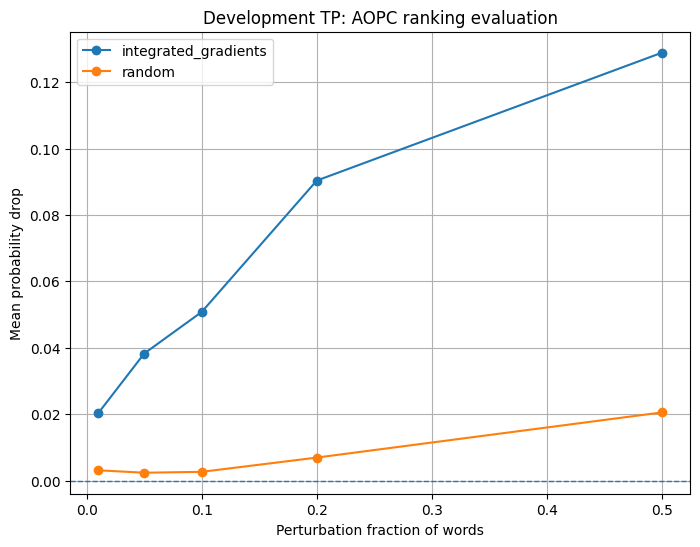

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_train_val_tp_curve_ig_vs_random.png


In [24]:
plot_df = dev_aopc_curve_summary.sort_values(
    ["ranking_method", "perturbation_fraction"]
).copy()

plt.figure(figsize=(8, 6))

for ranking_method in sorted(plot_df["ranking_method"].unique()):
    subset = plot_df[
        plot_df["ranking_method"] == ranking_method
    ].sort_values("perturbation_fraction")
    
    plt.plot(
        subset["perturbation_fraction"],
        subset["mean_prob_drop"],
        marker="o",
        label=ranking_method
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Perturbation fraction of words")
plt.ylabel("Mean probability drop")
plt.title("Development TP: AOPC ranking evaluation")
plt.grid(True)
plt.legend()

plot_path = aopc_output_dir / "ig_aopc_dev_train_val_tp_curve_ig_vs_random.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

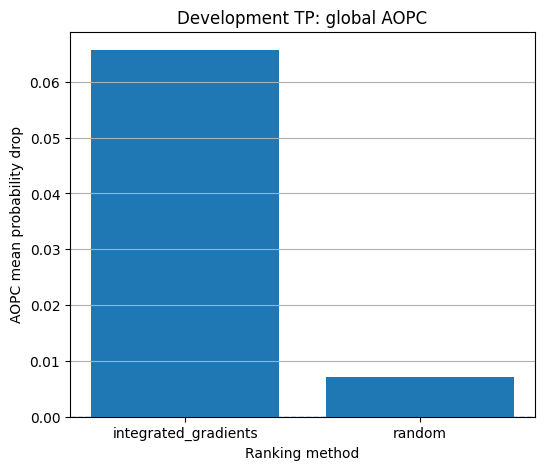

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_dev_train_val_tp_global_bar.png


In [25]:
plot_df = dev_aopc_global_summary.sort_values("ranking_method").copy()

plt.figure(figsize=(6, 5))

plt.bar(
    plot_df["ranking_method"],
    plot_df["aopc_mean_prob_drop"]
)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ranking method")
plt.ylabel("AOPC mean probability drop")
plt.title("Development TP: global AOPC")
plt.grid(axis="y")

plot_path = aopc_output_dir / "ig_aopc_dev_train_val_tp_global_bar.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## Config Search

In [24]:
dev_tp_results = run_ig_config_on_indices(
    df=dev_df,
    matrix_positions=dev_tp_positions,
    quantile_values=QUANTILE_VALUES,
    window_size_values=WINDOW_SIZE_VALUES,
    mask_token=MASK_TOKEN,
    ig_cache=dev_ig_cache
)

dev_tp_argument_df = build_argument_level_df(dev_tp_results)
dev_tp_span_df = build_span_level_df(dev_tp_results)

display(dev_tp_argument_df.head())
display(dev_tp_span_df.head())

Building raw-token IG spans:   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/1965 [00:00<?, ?it/s]

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,ig_convergence_delta,was_truncated,text,masked_text,error
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[3, 7, 13, 17, 23, 33, 39]","[7, 22, 47, 66, 103, 144, 174]","[11, 29, 58, 75, 105, 151, 190]","[""▁can"", ""t"", ""▁to"", ""▁wear"", ""▁i"", ""▁mean"", ""...","[{""char_start"": 7, ""char_end"": 11, ""token_star...",-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...,None
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[3, 7, 17, 23, 33, 39]","[7, 22, 47, 103, 144, 174]","[11, 29, 75, 105, 151, 190]","[""▁can"", ""t"", ""▁to"", ""▁wear"", ""▁i"", ""▁mean"", ""...","[{""char_start"": 7, ""char_end"": 11, ""token_star...",-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...,None
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[7, 17, 23, 33, 39]","[7, 47, 103, 144, 174]","[29, 75, 105, 151, 190]","[""▁can"", ""t"", ""▁to"", ""▁wear"", ""▁i"", ""▁mean"", ""...","[{""char_start"": 7, ""char_end"": 29, ""token_star...",-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[17, 23, 39]","[7, 103, 144]","[75, 105, 190]","[""▁can"", ""t"", ""▁to"", ""▁wear"", ""▁i"", ""▁mean"", ""...","[{""char_start"": 7, ""char_end"": 75, ""token_star...",-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[3, 7, 13, 16, 33, 39]","[7, 22, 47, 66, 144, 174]","[11, 29, 58, 73, 151, 190]","[""▁can"", ""t"", ""▁to"", ""▁wear"", ""▁i"", ""▁mean"", ""...","[{""char_start"": 7, ""char_end"": 11, ""token_star...",-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,ig_convergence_delta,was_truncated,text,masked_text
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.03741,0.959623,42,16,0.380952,0.380952,-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.03741,0.959623,42,16,0.380952,0.380952,-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.03741,0.959623,42,16,0.380952,0.380952,-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.03741,0.959623,42,16,0.380952,0.380952,-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,0.03741,0.959623,42,16,0.380952,0.380952,-12.00583,False,"people cant be forced to wear school uniforms,...",people [MASK] [MASK] be forced [MASK] [MASK] s...


In [25]:
dev_tp_argument_df_valid = dev_tp_argument_df[
    dev_tp_argument_df["error"].isna()
].copy()

dev_config_summary = (
    dev_tp_argument_df_valid
    .groupby(["attribution_method", "attribution_unit", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_n_selected_tokens=("n_selected_tokens", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        median_total_masked_tokens=("total_masked_tokens", "median"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        mean_selected_token_ratio=("selected_token_ratio", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

span_len_summary = (
    dev_tp_span_df
    .groupby(["attribution_method", "attribution_unit", "window_size", "quantile"])
    .agg(
        n_spans=("span_text", "count"),
        mean_span_len_tokens=("span_len_tokens", "mean"),
        median_span_len_tokens=("span_len_tokens", "median"),
        mean_span_len_chars=("span_len_chars", "mean"),
        median_span_len_chars=("span_len_chars", "median"),
        mean_span_score_sum_ig=("span_score_sum_ig", "mean"),
        mean_span_score_mean_ig=("span_score_mean_ig", "mean"),
    )
    .reset_index()
)

dev_config_summary = dev_config_summary.merge(
    span_len_summary,
    on=["attribution_method", "attribution_unit", "window_size", "quantile"],
    how="left"
)

dev_config_summary["prob_drop_per_masked_token"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_total_masked_tokens"].replace(0, np.nan)
)

dev_config_summary["prob_drop_per_masked_ratio"] = (
    dev_config_summary["mean_prob_drop"] /
    dev_config_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

dev_config_summary = dev_config_summary.sort_values(
    ["attribution_method", "attribution_unit", "window_size", "quantile"]
)

display(dev_config_summary)

,attribution_method,attribution_unit,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,...,truncation_rate,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_ig,mean_span_score_mean_ig,prob_drop_per_masked_token,prob_drop_per_masked_ratio
0,integrated_gradients,raw_token,0,0.30,873,0.121499,0.005743,0.260044,0.923253,0.420389,...,0.0,16104,2.142884,2.0,8.726776,6.0,0.039641,0.016979,0.003074,0.266163
1,integrated_gradients,raw_token,0,0.40,873,0.111840,0.003461,0.258966,0.914089,0.333333,...,0.0,15307,1.939897,1.0,7.749657,6.0,0.040209,0.019219,0.003288,0.284183
2,integrated_gradients,raw_token,0,0.50,873,0.104242,0.002233,0.257339,0.920962,0.268041,...,0.0,14172,1.761431,1.0,6.861981,5.0,0.041419,0.022082,0.003646,0.313386
3,integrated_gradients,raw_token,0,0.60,873,0.092005,0.001673,0.248309,0.914089,0.224513,...,0.0,12385,1.612515,1.0,6.061526,5.0,0.044160,0.026278,0.004022,0.345705
4,integrated_gradients,raw_token,0,0.70,873,0.074793,0.001206,0.227884,0.910653,0.197022,...,0.0,10311,1.460285,1.0,5.177383,4.0,0.048111,0.032361,0.004336,0.371921
5,integrated_gradients,raw_token,0,0.80,873,0.058762,0.000852,0.204082,0.891180,0.148912,...,0.0,7850,1.304204,1.0,4.143185,3.0,0.054895,0.042047,0.005011,0.424516
6,integrated_gradients,raw_token,0,0.85,873,0.046594,0.000715,0.185147,0.857961,0.117984,...,0.0,6349,1.220350,1.0,3.508584,1.0,0.060720,0.050029,0.005250,0.443035
7,integrated_gradients,raw_token,0,0.90,873,0.037685,0.000520,0.167575,0.833906,0.101947,...,0.0,4718,1.128444,1.0,2.822382,1.0,0.069985,0.062460,0.006179,0.511017
8,integrated_gradients,raw_token,0,0.95,873,0.035504,0.000203,0.162532,0.689576,0.095074,...,0.0,2740,1.050365,1.0,2.135766,1.0,0.089444,0.085820,0.010770,0.864651
9,integrated_gradients,raw_token,1,0.30,873,0.138404,0.006568,0.274451,0.916380,0.445590,...,0.0,10172,3.976111,3.0,16.808396,11.0,0.062765,0.017666,0.002987,0.258748


In [26]:
dev_output_dir = OUTPUT_DIR / "dev_config_selection"
dev_output_dir.mkdir(parents=True, exist_ok=True)

dev_tp_argument_df.to_csv(
    dev_output_dir / "ig_dev_tp_argument_level.csv",
    index=False,
    encoding="utf-8"
)

dev_tp_span_df.to_csv(
    dev_output_dir / "ig_dev_tp_span_level.csv",
    index=False,
    encoding="utf-8"
)

dev_config_summary.to_csv(
    dev_output_dir / "ig_dev_config_summary.csv",
    index=False,
    encoding="utf-8"
)

print("Saved dev config selection files to:", dev_output_dir)

Saved dev config selection files to: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection


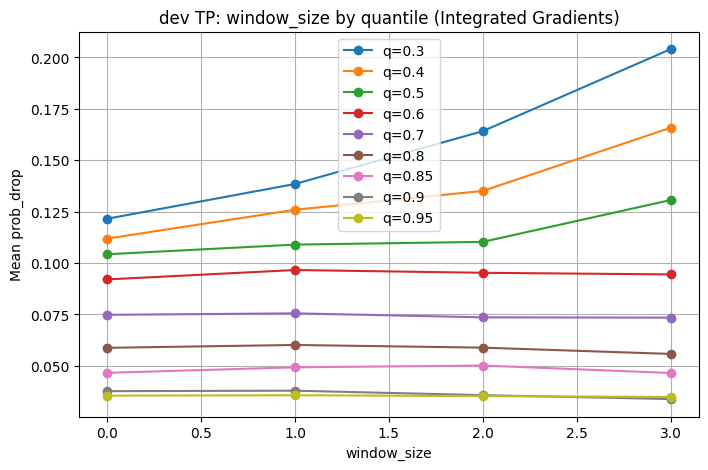

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection/ig_dev_window_by_quantile.png


In [27]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 5))

for quantile in sorted(method_df["quantile"].unique()):
    subset = method_df[
        method_df["quantile"] == quantile
    ].sort_values("window_size")
    
    plt.plot(
        subset["window_size"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"q={quantile}"
    )

plt.xlabel("window_size")
plt.ylabel("Mean prob_drop")
plt.title("dev TP: window_size by quantile (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_window_by_quantile.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

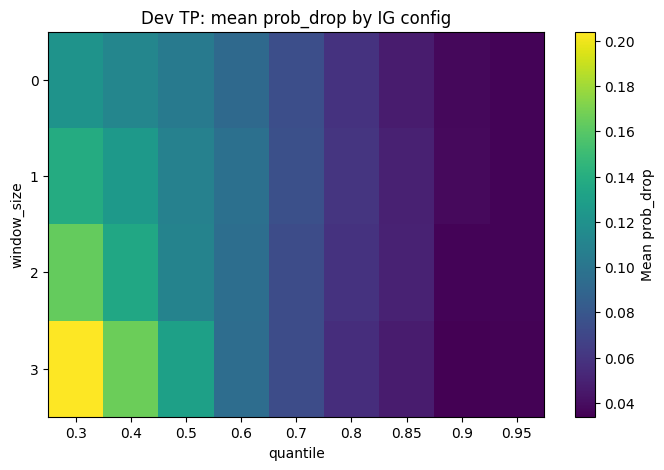

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection/ig_dev_find_config_heatmap.png


quantile,0.30,0.40,0.50,0.60,0.70,0.80,0.85,0.90,0.95
window_size,,,,,,,,,
0,0.121499,0.111840,0.104242,0.092005,0.074793,0.058762,0.046594,0.037685,0.035504
1,0.138404,0.125868,0.108934,0.096581,0.075524,0.060147,0.049274,0.037922,0.035701
2,0.164107,0.135026,0.110262,0.095228,0.073581,0.058843,0.050148,0.035748,0.035280
3,0.203987,0.165757,0.130610,0.094443,0.073430,0.055789,0.046523,0.033837,0.034854


In [28]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

heatmap_data = method_df.pivot(
    index="window_size",
    columns="quantile",
    values="mean_prob_drop"
)

plt.figure(figsize=(8, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean prob_drop")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("quantile")
plt.ylabel("window_size")
plt.title("Dev TP: mean prob_drop by IG config")

plot_path = dev_output_dir / "ig_dev_find_config_heatmap.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)
display(heatmap_data)

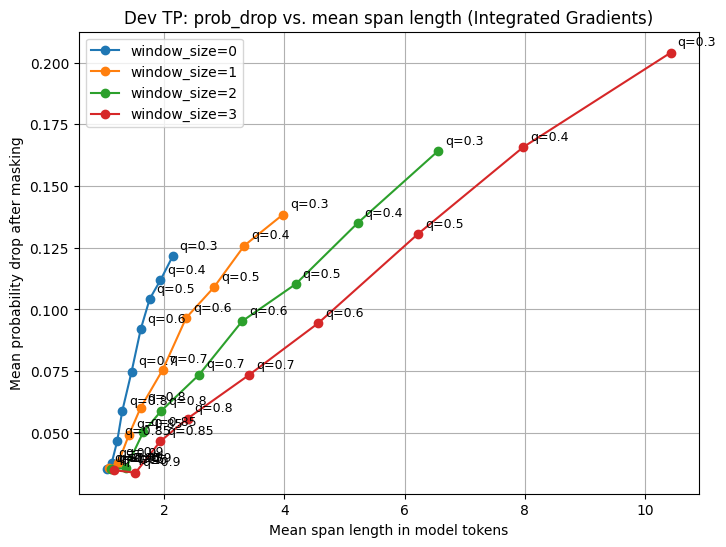

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection/ig_dev_prob_drop_vs_mean_span_len.png


In [29]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_span_len_tokens"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_span_len_tokens"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean span length in model tokens")
plt.ylabel("Mean probability drop after masking")
plt.title("Dev TP: prob_drop vs. mean span length (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_prob_drop_vs_mean_span_len.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

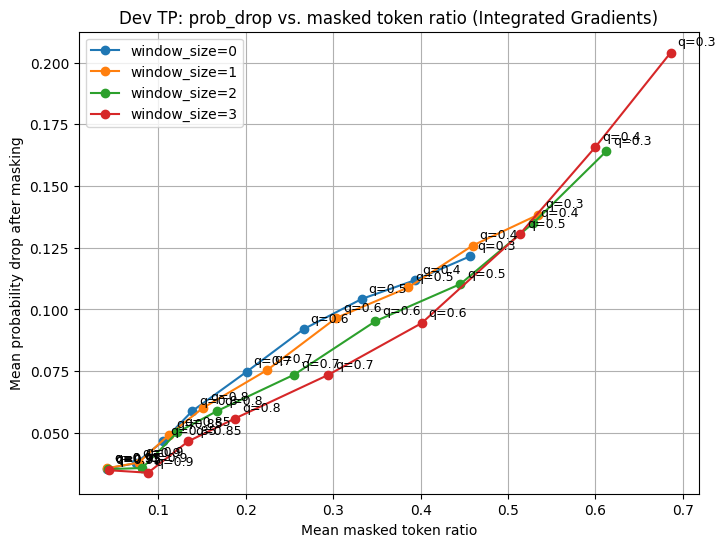

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection/ig_dev_prob_drop_vs_masked_token_ratio.png


In [30]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title("Dev TP: prob_drop vs. masked token ratio (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

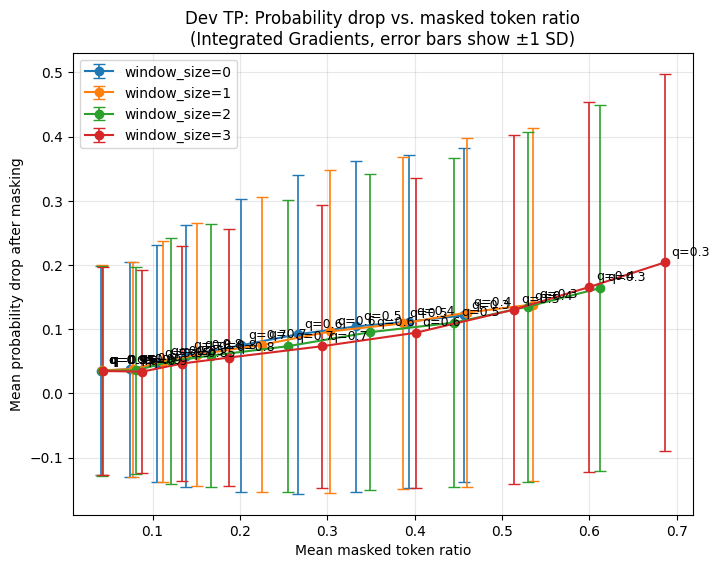

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection/ig_dev_prob_drop_vs_masked_token_ratio_with_std.png


In [31]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")

    plt.errorbar(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        yerr=subset["std_prob_drop"],
        marker="o",
        linestyle="-",
        capsize=4,
        elinewidth=1.2,
        label=f"window_size={window_size}"
    )

    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (
                row["mean_masked_token_ratio"],
                row["mean_prob_drop"]
            ),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean probability drop after masking")
plt.title(
    "Dev TP: Probability drop vs. masked token ratio\n"
    "(Integrated Gradients, error bars show ±1 SD)"
)
plt.grid(True, alpha=0.3)
plt.legend()

plot_path = (
    dev_output_dir
    / "ig_dev_prob_drop_vs_masked_token_ratio_with_std.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Saved plot:", plot_path)

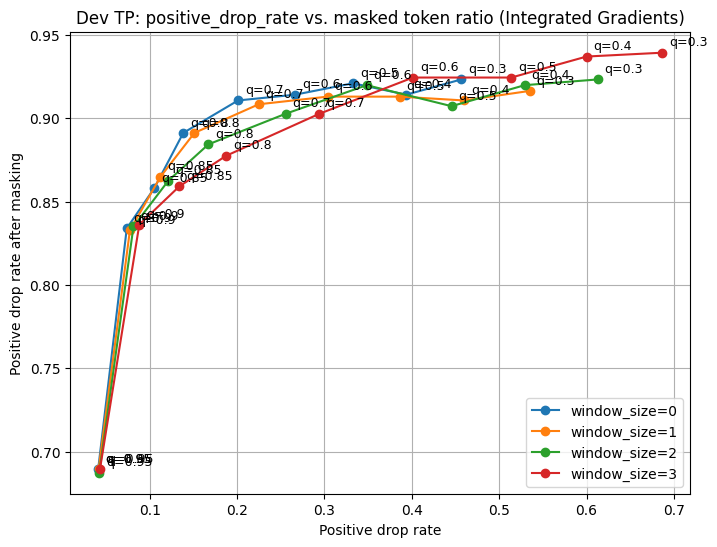

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/dev_config_selection/ig_dev_positive_drop_rate_vs_masked_token_ratio.png


In [32]:
method_df = dev_config_summary[
    dev_config_summary["attribution_method"] == "integrated_gradients"
].copy()

plt.figure(figsize=(8, 6))

for window_size in sorted(method_df["window_size"].unique()):
    subset = method_df[
        method_df["window_size"] == window_size
    ].sort_values("quantile")
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["positive_drop_rate"],
        marker="o",
        label=f"window_size={window_size}"
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"q={row['quantile']}",
            (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.xlabel("Positive drop rate")
plt.ylabel("Positive drop rate after masking")
plt.title("Dev TP: positive_drop_rate vs. masked token ratio (Integrated Gradients)")
plt.grid(True)
plt.legend()

plot_path = dev_output_dir / "ig_dev_positive_drop_rate_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [34]:
# Final config selected from validation plots and summary.
# dev_config_summary = pd.read_csv("ig_results_new/dev_config_selection/ig_dev_config_summary.csv")

BEST_QUANTILE = 0.4
BEST_WINDOW_SIZE = 1

selected_config_summary = dev_config_summary[
    (dev_config_summary["attribution_method"] == "integrated_gradients") &
    (dev_config_summary["quantile"] == BEST_QUANTILE) &
    (dev_config_summary["window_size"] == BEST_WINDOW_SIZE)
]

display(selected_config_summary)

,attribution_method,attribution_unit,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,...,truncation_rate,n_spans,mean_span_len_tokens,median_span_len_tokens,mean_span_len_chars,median_span_len_chars,mean_span_score_sum_ig,mean_span_score_mean_ig,prob_drop_per_masked_token,prob_drop_per_masked_ratio
10,integrated_gradients,raw_token,1,0.4,873,0.125868,0.004047,0.271733,0.910653,0.363116,...,0.0,10380,3.335742,2.0,13.85395,9.0,0.0593,0.01994,0.003173,0.273904


In [35]:
def show_ig_example(result_df, index=0):
    """Display one IG result with highlighted masked spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attribution_method"]))} |
        <b>quantile:</b> {row["quantile"]} |
        <b>window_size:</b> {row["window_size"]}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_masked:</b> {float(row["p_inappropriate_masked"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <b>IG convergence delta:</b> {float(row["ig_convergence_delta"]):.6f}<br>
        <hr>
        <p>{marked}</p>
    </div>
    """))

In [36]:
dev_best_examples = dev_tp_argument_df[
    (dev_tp_argument_df["attribution_method"] == "integrated_gradients") &
    (dev_tp_argument_df["quantile"] == BEST_QUANTILE) &
    (dev_tp_argument_df["window_size"] == BEST_WINDOW_SIZE) &
    (dev_tp_argument_df["error"].isna())
].copy()

print("Dev examples for selected IG config:", len(dev_best_examples))

display(
    dev_best_examples[
        [
            "global_row_id",
            "post_id",
            "prob_drop",
            "masked_token_ratio",
            "merged_span_texts"
        ]
    ].head()
)

Dev examples for selected IG config: 873


,global_row_id,post_id,prob_drop,masked_token_ratio,merged_span_texts
5,0,1,0.968536,0.357143,"[cant, to wear, i mean each person has the, I ..."
41,1,2,0.001262,0.525000,"[form, forum, and will cause, common denominat..."
77,3,4,0.007084,0.562500,"[No I wouldn't turn in my spouse., the girl th..."
113,4,5,0.001697,0.513514,"[TV is terrible. Except for, ', , the majority..."
149,5,6,0.002201,0.600000,"[I love books, I love getting lost in them., (..."


In [37]:
tmp_top = (
    dev_best_examples
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_top))):
    show_ig_example(tmp_top, index=i)

# Run AOPC on test TP

In [26]:
test_tp_positions = test_df.index[
    test_df["confusion_type"] == "TP"
].tolist()

print("Test examples:", len(test_df))
print("Test true positives:", len(test_tp_positions))

test_aopc_df = run_ig_aopc_on_indices(
    df=test_df,
    matrix_positions=test_tp_positions,
    fractions=AOPC_FRACTIONS,
    classifier=pipe,
    random_runs=AOPC_RANDOM_RUNS,
    random_seed=AOPC_RANDOM_SEED,
    mask_token=MASK_TOKEN
)

test_aopc_step_df, test_aopc_curve_summary, test_aopc_per_argument, test_aopc_global_summary = summarize_aopc_results(
    test_aopc_df
)

display(test_aopc_curve_summary)
display(test_aopc_global_summary)

Test examples: 438
Test true positives: 186


AOPC raw-token ranking evaluation:   0%|          | 0/186 [00:00<?, ?it/s]

AOPC masked-text inference:   0%|          | 0/640 [00:00<?, ?it/s]

AOPC valid rows: 10230 of 10230


,ranking_method,perturbation_fraction,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_token_ratio,mean_top_k_tokens,mean_total_masked_tokens,mean_n_merged_spans
0,integrated_gradients,0.01,186,0.029286,-0.000005,0.137220,0.494624,0.981553,0.952267,0.023032,0.016065,0.023032,1.413978,1.413978,1.403226
1,integrated_gradients,0.05,186,0.028829,0.000313,0.144584,0.741935,0.981553,0.952724,0.058111,0.055556,0.058111,4.849462,4.849462,4.478495
2,integrated_gradients,0.10,186,0.022306,0.000630,0.152214,0.811828,0.981553,0.959247,0.108701,0.104938,0.108701,9.241935,9.241935,7.569892
3,integrated_gradients,0.20,186,0.047492,0.000958,0.185941,0.870968,0.981553,0.934061,0.208118,0.204463,0.208118,18.016129,18.016129,12.333333
4,integrated_gradients,0.50,186,0.076512,0.005158,0.203681,0.930108,0.981553,0.905041,0.504578,0.500000,0.504578,44.263441,44.263441,18.317204
5,random,0.01,186,0.000021,0.000002,0.030281,0.516129,0.981553,0.981533,0.023032,0.016065,0.023032,1.413978,1.413978,1.410215
6,random,0.05,186,-0.005099,0.000110,0.043207,0.693548,0.981553,0.986653,0.058111,0.055556,0.058111,4.849462,4.849462,4.635484
7,random,0.10,186,-0.002657,0.000226,0.046763,0.741935,0.981553,0.984210,0.108701,0.104938,0.108701,9.241935,9.241935,8.358065
8,random,0.20,186,-0.003457,0.000436,0.067494,0.758065,0.981553,0.985011,0.208112,0.204463,0.208118,18.016129,18.015591,14.547312
9,random,0.50,186,-0.002424,0.002405,0.066748,0.876344,0.981553,0.983978,0.504572,0.500000,0.504578,44.263441,44.262903,22.477957


,ranking_method,n_arguments,aopc_mean_prob_drop,aopc_median_prob_drop,aopc_std_prob_drop,mean_positive_steps_rate,mean_masked_token_ratio,mean_max_masked_token_ratio,mean_total_masked_tokens
0,integrated_gradients,186,0.040885,0.001835,0.124758,0.769892,0.180508,0.504578,15.556989
1,random,186,-0.002723,0.000753,0.044847,0.717204,0.180506,0.504572,15.556774


In [27]:
save_aopc_outputs(
    aopc_df=test_aopc_df,
    step_df=test_aopc_step_df,
    curve_summary=test_aopc_curve_summary,
    per_argument_aopc=test_aopc_per_argument,
    global_summary=test_aopc_global_summary,
    output_dir=aopc_output_dir,
    prefix="ig_aopc_test_tp",
)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_raw.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_step_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_curve_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_per_argument.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_global_summary.csv


{'raw': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_raw.csv'),
 'step': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_step_summary.csv'),
 'curve': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_curve_summary.csv'),
 'per_argument': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_per_argument.csv'),
 'global': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_global_summary.csv')}

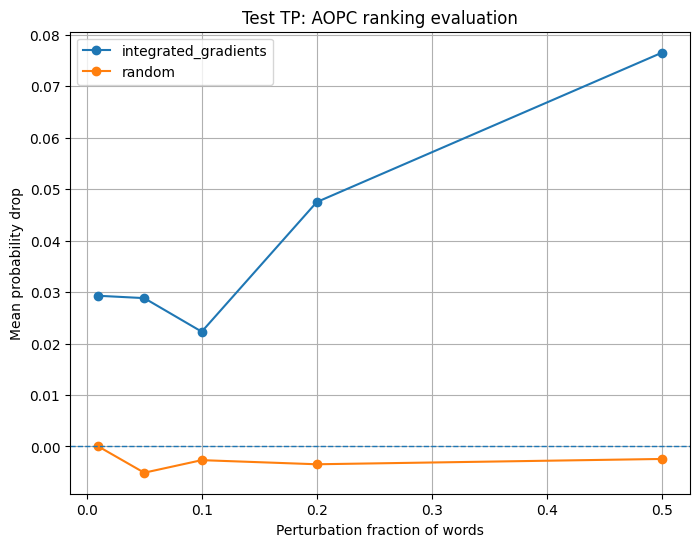

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_curve_ig_vs_random.png


In [28]:
plot_df = test_aopc_curve_summary.sort_values(
    ["ranking_method", "perturbation_fraction"]
).copy()

plt.figure(figsize=(8, 6))

for ranking_method in sorted(plot_df["ranking_method"].unique()):
    subset = plot_df[
        plot_df["ranking_method"] == ranking_method
    ].sort_values("perturbation_fraction")
    
    plt.plot(
        subset["perturbation_fraction"],
        subset["mean_prob_drop"],
        marker="o",
        label=ranking_method
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Perturbation fraction of words")
plt.ylabel("Mean probability drop")
plt.title("Test TP: AOPC ranking evaluation")
plt.grid(True)
plt.legend()

plot_path = aopc_output_dir / "ig_aopc_test_tp_curve_ig_vs_random.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

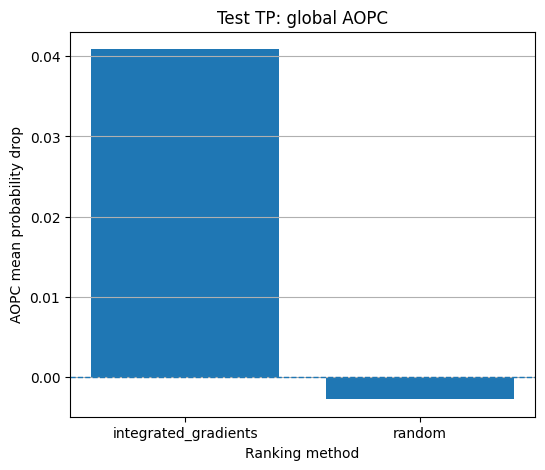

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results/aopc_ranking_evaluation/ig_aopc_test_tp_global_bar.png


In [29]:
plot_df = test_aopc_global_summary.sort_values("ranking_method").copy()

plt.figure(figsize=(6, 5))

plt.bar(
    plot_df["ranking_method"],
    plot_df["aopc_mean_prob_drop"]
)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Ranking method")
plt.ylabel("AOPC mean probability drop")
plt.title("Test TP: global AOPC")
plt.grid(axis="y")

plot_path = aopc_output_dir / "ig_aopc_test_tp_global_bar.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

## Final selected Integrated Gradients configuration

The final IG configuration is selected on validation true positives only. This keeps the hyperparameter choice separate from the final test evaluation.

The final configuration is based on:

- word-level Integrated Gradients scores,
- positive attribution scores for the `inappropriate` class,
- span extraction via quantile thresholding,
- local span merging through `window_size`,
- masking-based validation on validation true positives.

A separate word-boundary post-processing step is not necessary here because subword attributions are aggregated to full words before spans are constructed.

Selected final configuration:

- `quantile = 0.85`
- `window_size = 3`

# Run best config

The selected configuration is now applied to the full train, validation, and test splits.

The configuration is not re-tuned on the test set. The test split is only used for final reporting.

In [41]:
def run_final_ig_on_split(df, split_name):
    """
    Run the selected IG configuration on one split.
    
    The final configuration is fixed and not re-tuned per split.
    """
    positions = list(range(len(df)))
    
    results = run_ig_config_on_indices(
        df=df,
        matrix_positions=positions,
        quantile_values=[BEST_QUANTILE],
        window_size_values=[BEST_WINDOW_SIZE],
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_argument_level_df(results)
    span_df = build_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


# train_results, train_argument_df, train_span_df = run_final_ig_on_split(
#     train_df,
#     "train"
# )

# val_results, val_argument_df, val_span_df = run_final_ig_on_split(
#     val_df,
#     "validation"
# )

test_results, test_argument_df, test_span_df = run_final_ig_on_split(
    test_df,
    "test"
)

Building raw-token IG spans:   0%|          | 0/438 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/28 [00:00<?, ?it/s]

test argument level: (438, 42)
test span level: (5299, 40)


In [42]:
final_argument_df = pd.concat(
    [test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [test_span_df],
    ignore_index=True
)

display(final_argument_df.head())
display(final_span_df.head())

print("Final argument-level rows:", len(final_argument_df))
print("Final span-level rows:", len(final_span_df))

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_token_end_indices,merged_span_char_start_indices,merged_span_char_end_indices,selected_tokens_json,merged_spans_json,ig_convergence_delta,was_truncated,text,masked_text,error
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,0.892727,FN,False,True,...,[3],[0],[20],"[""▁students"", ""▁wear""]","[{""char_start"": 0, ""char_end"": 20, ""token_star...",-0.340958,False,students should wear what they like and feel f...,[MASK] [MASK] [MASK] what they like and feel f...,None
1,1754,test,8,Tv is better than books:,1,LABEL_1,0.997475,TP,True,False,...,"[2, 8, 17, 20, 26]","[0, 18, 53, 78, 98]","[7, 36, 69, 83, 100]","[""▁I"", ""▁thick"", ""▁are"", ""▁better"", ""▁than"", ""...","[{""char_start"": 0, ""char_end"": 7, ""token_start...",-0.697400,False,I thick that book are better than TV is it is ...,[MASK] [MASK] that book [MASK] [MASK] [MASK] [...,None
2,1755,test,9,Tv is better than books:,1,LABEL_1,0.998255,TP,True,False,...,"[1, 6, 9, 15, 22, 25, 40, 56, 69, 74, 78, 90]","[0, 24, 36, 68, 98, 117, 153, 272, 305, 350, 3...","[5, 31, 37, 69, 104, 118, 196, 282, 325, 351, ...","[""▁Books"", ""."", ""▁Books"", ""t"", ""."", ""▁series"",...","[{""char_start"": 0, ""char_end"": 5, ""token_start...",-1.330750,False,Books enlighten the soul. Books don't destroy ...,[MASK] enlighten the soul[MASK] [MASK] don'[MA...,None
3,1756,test,12,India has the potential to lead the world:,1,LABEL_1,0.995627,TP,True,False,...,"[4, 8, 16]","[0, 31, 56]","[16, 34, 83]","[""▁india"", ""▁is"", ""▁good"", ""▁bad"", ""▁should"", ...","[{""char_start"": 0, ""char_end"": 16, ""token_star...",-1.468317,False,india is is good adopter but a bad developer a...,[MASK] [MASK] [MASK] [MASK] adopter but a [MAS...,None
4,1757,test,15,Is it better to have a lousy father or to be f...,0,LABEL_0,0.993661,TN,False,False,...,"[2, 6, 10, 14, 24, 42, 50, 63, 70, 76, 84, 89,...","[8, 14, 41, 51, 108, 190, 213, 274, 335, 364, ...","[9, 20, 45, 62, 109, 197, 236, 306, 337, 367, ...","["","", ""▁rather"", ""less"", ""▁saying"", ""▁that"", ""...","[{""char_start"": 8, ""char_end"": 9, ""token_start...",-0.748162,False,"Honestly, I'd rather be completely fatherless,...",Honestly[MASK] I'd [MASK] be completely father...,None


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,p_inappropriate_masked,prob_drop,n_model_tokens,n_selected_tokens,selected_token_ratio,masked_token_ratio,ig_convergence_delta,was_truncated,text,masked_text
0,1753,test,0,Is the school uniform a good or bad idea:,1,LABEL_0,FN,False,True,False,...,0.955027,-0.847753,12,2,0.166667,0.250000,-0.340958,False,students should wear what they like and feel f...,[MASK] [MASK] [MASK] what they like and feel f...
1,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.987871,0.009604,27,12,0.444444,0.481481,-0.697400,False,I thick that book are better than TV is it is ...,[MASK] [MASK] that book [MASK] [MASK] [MASK] [...
2,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.987871,0.009604,27,12,0.444444,0.481481,-0.697400,False,I thick that book are better than TV is it is ...,[MASK] [MASK] that book [MASK] [MASK] [MASK] [...
3,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.987871,0.009604,27,12,0.444444,0.481481,-0.697400,False,I thick that book are better than TV is it is ...,[MASK] [MASK] that book [MASK] [MASK] [MASK] [...
4,1754,test,8,Tv is better than books:,1,LABEL_1,TP,True,False,False,...,0.987871,0.009604,27,12,0.444444,0.481481,-0.697400,False,I thick that book are better than TV is it is ...,[MASK] [MASK] that book [MASK] [MASK] [MASK] [...


Final argument-level rows: 438
Final span-level rows: 5299


In [43]:
final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

overall_summary = (
    final_argument_df_valid
    .groupby(["split", "attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

confusion_summary = (
    final_argument_df_valid
    .groupby(["split", "confusion_type"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

display(overall_summary)
display(confusion_summary)

,split,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta,truncation_rate
0,test,integrated_gradients,1,0.4,438,-0.067539,0.000801,0.377243,0.534247,0.191781,0.130137,0.590803,0.658342,12.098174,35.618721,0.394639,-0.621088,0.0


,split,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta
0,test,FN,39,-0.443327,-0.278210,0.370278,0.051282,0.049637,0.492965,13.102564,35.102564,0.327010,0.632668
1,test,FP,71,0.185257,0.003677,0.334453,0.802817,0.971583,0.786326,11.281690,33.422535,0.420301,-0.558073
2,test,TN,142,-0.284273,-0.116815,0.360261,0.084507,0.037214,0.321488,12.978873,32.774648,0.298932,-0.085871
3,test,TP,186,0.080222,0.003074,0.233355,0.876344,0.981553,0.901332,11.526882,38.736559,0.472091,-1.316634


In [44]:
test_argument_df_valid = test_argument_df[
    test_argument_df["error"].isna()
].copy()

test_overall_summary = (
    test_argument_df_valid
    .groupby(["attribution_method", "window_size", "quantile"])
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        strong_drop_rate_001=("prob_drop", lambda x: (x > 0.01).mean()),
        strong_drop_rate_005=("prob_drop", lambda x: (x > 0.05).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
        truncation_rate=("was_truncated", lambda x: x.mean()),
    )
    .reset_index()
)

test_confusion_summary = (
    test_argument_df_valid
    .groupby("confusion_type")
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        positive_drop_rate=("prob_drop", lambda x: (x > 0).mean()),
        mean_p_original=("p_inappropriate_original", "mean"),
        mean_p_masked=("p_inappropriate_masked", "mean"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        mean_ig_convergence_delta=("ig_convergence_delta", "mean"),
    )
    .reset_index()
    .sort_values("confusion_type")
)

display(test_overall_summary)
display(test_confusion_summary)

,attribution_method,window_size,quantile,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta,truncation_rate
0,integrated_gradients,1,0.4,438,-0.067539,0.000801,0.377243,0.534247,0.191781,0.130137,0.590803,0.658342,12.098174,35.618721,0.394639,-0.621088,0.0


,confusion_type,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_p_original,mean_p_masked,mean_n_merged_spans,mean_total_masked_tokens,mean_masked_token_ratio,mean_ig_convergence_delta
0,FN,39,-0.443327,-0.278210,0.370278,0.051282,0.049637,0.492965,13.102564,35.102564,0.327010,0.632668
1,FP,71,0.185257,0.003677,0.334453,0.802817,0.971583,0.786326,11.281690,33.422535,0.420301,-0.558073
2,TN,142,-0.284273,-0.116815,0.360261,0.084507,0.037214,0.321488,12.978873,32.774648,0.298932,-0.085871
3,TP,186,0.080222,0.003074,0.233355,0.876344,0.981553,0.901332,11.526882,38.736559,0.472091,-1.316634


In [45]:
final_output_dir = OUTPUT_DIR / "ig_results_final"
final_output_dir.mkdir(parents=True, exist_ok=True)

argument_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.csv"
)

span_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_span_level.csv"
)

overall_summary_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_overall_summary.csv"
)

confusion_summary_csv_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_confusion_summary.csv"
)

test_summary_csv_path = final_output_dir / (
    f"ig_final_test"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_summary.csv"
)

jsonl_path = final_output_dir / (
    f"ig_final_all_splits"
    f"_q{BEST_QUANTILE}_window{BEST_WINDOW_SIZE}_argument_level.jsonl"
)

final_argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
final_span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
overall_summary.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")
confusion_summary.to_csv(confusion_summary_csv_path, index=False, encoding="utf-8")
test_overall_summary.to_csv(test_summary_csv_path, index=False, encoding="utf-8")

all_results = test_results

with open(jsonl_path, "w", encoding="utf-8") as f:
    for result in all_results:
        safe_result = make_json_serializable(result)
        f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")

print("Saved:")
print(argument_csv_path)
print(span_csv_path)
print(overall_summary_csv_path)
print(confusion_summary_csv_path)
print(test_summary_csv_path)
print(jsonl_path)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/ig_results_final/ig_final_all_splits_q0.4_window1_argument_level.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/ig_results_final/ig_final_all_splits_q0.4_window1_span_level.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/ig_results_final/ig_final_all_splits_q0.4_window1_overall_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/ig_results_final/ig_final_all_splits_q0.4_window1_confusion_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/ig_results_final/ig_final_test_q0.4_window1_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ig_results_test/ig_results_final/ig_final_all_splits_q0.4_window1_argument_level.jsonl


In [46]:
# Best test examples by probability drop
tmp = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp))):
    show_ig_example(tmp, index=i)

In [47]:
# Test examples with the smallest or negative probability drops
tmp_low = (
    test_argument_df_valid
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

for i in range(min(5, len(tmp_low))):
    show_ig_example(tmp_low, index=i)